In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.485459,0.064971,0.106464,0.059912,0.040088,0.016991,-0.128772,0.030929,0.088920,-0.225260,...,1.259511,-0.187895,-0.237601,0.332001,0.000000,-0.255811,-0.228027,0.038290,-0.362826,-0.200426
1,0.666232,-0.952446,-1.099567,-0.755402,-0.875769,-0.824341,-0.652457,-0.744926,-0.477418,-0.603339,...,3.566490,3.137073,0.913224,-1.314176,0.000000,2.591499,1.070407,1.827361,1.866886,0.869468
2,0.337179,0.444285,0.660909,0.338093,0.468616,0.259750,0.440538,0.543698,0.630069,0.754279,...,0.000000,0.082981,0.129427,0.390580,0.524263,-0.050487,-0.580607,-0.345359,-0.452526,-0.057457
3,0.695653,-0.718597,-0.979079,-0.709822,-0.930040,-0.881308,-0.331090,-0.564759,-0.457375,-0.522339,...,3.059892,2.449854,0.967575,-1.179161,0.000000,0.280373,1.104438,-0.345359,1.114908,1.522258
4,0.617917,-0.496529,-0.535096,-0.285114,-0.602328,-0.244920,-0.174518,-0.266658,-0.386906,0.069107,...,0.000000,0.190665,0.869189,-1.477904,3.028668,2.691677,1.352218,2.133915,2.946000,3.137491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.105628,-0.004852,-0.358757,-0.360532,-0.402004,-0.263575,-0.567218,-0.358084,-0.246111,-0.455811,...,0.000000,-0.007844,-0.258121,0.163381,0.000000,-0.508000,0.087068,-0.345359,-0.405549,-0.231420
135,0.267171,1.278289,0.793049,0.011834,0.186224,0.312548,0.304548,0.236335,0.478786,0.257736,...,0.401955,0.179343,0.399712,-0.028726,0.000000,0.619505,-0.164891,0.144386,-0.060514,0.645662
136,0.324219,0.748713,0.215283,-0.194798,-0.504568,-0.064017,0.452283,-0.154471,0.051287,0.016210,...,0.000000,-0.577753,-0.765863,0.578039,0.000000,-0.732668,-0.221085,-0.345359,-0.504845,0.294840
137,-0.351598,-0.195069,0.112013,0.237230,0.100387,0.086725,0.028168,0.200249,0.183658,0.069765,...,0.000000,-0.253379,0.106163,-0.097845,0.000000,0.215431,0.189762,-0.008205,-0.032466,0.889136


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

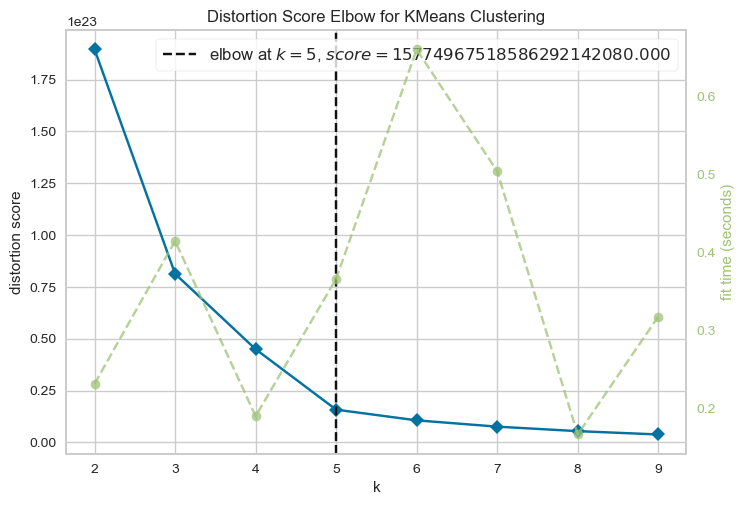

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: glrlm_ShortRunLowGrayLevelEmphasis_CT_b20, Coefficient: -1.8614542329787187


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: glszm_LargeAreaLowGrayLevelEmphasis_PET_c04, Coefficient: 0.00150259687345959


...

Cluster 2: Most important feature: glszm_LargeAreaEmphasis_PET_c04, Coefficient: 0.12560939991651457


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 3: Most important feature: shape_VoxelVolume, Coefficient: 0.690025797743198


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 4: Most important feature: glrlm_GrayLevelNonUniformityNormalized_CT_b20, Coefficient: -2.5105754674047724


In [22]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

# Standardization

In [23]:
# Do the standardization for X_fs_fi
scaler = RobustScaler() 
X_new_std= scaler.fit_transform(X_fs_fi)
X_new_std = pd.DataFrame(X_new_std,
                        columns=X_fs_fi.columns, 
                        index=X_fs_fi.index)

# Do the standardization for MAASTRO 
MAASTRO_new = X_MAASTRO[selected_features]
MAASTRO_new_std = scaler.transform(MAASTRO_new)
MAASTRO_new_std = pd.DataFrame(MAASTRO_new_std, 
                              columns=MAASTRO_new.columns, 
                              index=MAASTRO_new.index )

In [24]:
X_new

,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaEmphasis_PET_c04,shape_VoxelVolume,glrlm_GrayLevelNonUniformityNormalized_CT_b20
0,0.000536,879096.343994,3.392207e+06,16214.0,0.103193
1,0.001324,26566.901706,9.996325e+04,2863.0,0.121942
2,0.000455,647295.586841,4.566579e+06,28989.0,0.140952
3,0.000847,40145.962374,1.798434e+05,3337.0,0.098367
4,0.001143,10927.978256,1.231554e+05,5018.0,0.107915
...,...,...,...,...,...
134,0.001070,215024.891557,7.130061e+05,8321.0,0.151146
135,0.000553,338158.975184,4.579243e+06,25403.0,0.209582
136,0.000739,974304.249507,2.589594e+06,15322.0,0.172147
137,0.000770,199030.525466,1.972581e+06,18450.0,0.256433


In [25]:
X_new_std

,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaEmphasis_PET_c04,shape_VoxelVolume,glrlm_GrayLevelNonUniformityNormalized_CT_b20
0,-0.230645,0.627985,0.345099,0.088778,-0.847590
1,0.773474,-0.249270,-0.349687,-0.477795,-0.589551
2,-0.333883,0.389462,0.592935,0.630907,-0.327913
3,0.165736,-0.235297,-0.332829,-0.457680,-0.914007
4,0.543393,-0.265362,-0.344792,-0.386344,-0.782607
...,...,...,...,...,...
134,0.450506,-0.055346,-0.220312,-0.246175,-0.187607
135,-0.209520,0.071360,0.595608,0.478729,0.616641
136,0.027569,0.725955,0.175718,0.050924,0.101422
137,0.068003,-0.071804,0.045505,0.183666,1.261451


In [26]:
MAASTRO_new

,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaEmphasis_PET_c04,shape_VoxelVolume,glrlm_GrayLevelNonUniformityNormalized_CT_b20
0,0.000574,1.125054e+06,5.846775e+06,38115.0,0.230144
1,0.002657,1.948450e+06,3.873610e+06,17918.0,0.180915
2,0.000617,1.403912e+06,3.214991e+06,17475.0,0.203473
3,0.005186,4.555744e+05,1.459965e+06,12512.0,0.075273
4,0.000393,8.660429e+05,4.406102e+06,28361.0,0.218389
...,...,...,...,...,...
94,0.000635,9.500595e+05,1.483641e+06,12865.0,0.116181
95,0.003568,3.718008e+06,5.977704e+06,18413.0,0.094884
96,0.000344,2.726200e+06,1.178081e+07,35439.0,0.185765
97,0.000467,2.138315e+06,6.169522e+06,26221.0,0.112777


In [27]:
MAASTRO_new_std

,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaEmphasis_PET_c04,shape_VoxelVolume,glrlm_GrayLevelNonUniformityNormalized_CT_b20
0,-0.182714,0.881077,0.863105,1.018184,0.899642
1,2.473143,1.728353,0.446693,0.161090,0.222090
2,-0.127674,1.168022,0.307700,0.142290,0.532564
3,5.697766,0.192180,-0.062676,-0.068323,-1.231854
4,-0.413366,0.614553,0.559069,0.604256,0.737855
...,...,...,...,...,...
94,-0.104615,0.701007,-0.057679,-0.053343,-0.668839
95,3.635137,3.549233,0.890735,0.182096,-0.961952
96,-0.475501,2.528660,2.115407,0.904623,0.288849
97,-0.318530,1.923725,0.931216,0.513442,-0.715682


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 16:30:45,280] A new study created in memory with name: no-name-d82d8b73-74c1-4ec8-b736-cb9ccb720408


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7364341085271318
Fold 3 C-index: 0.33191489361702126


[I 2024-04-14 16:30:46,715] A new study created in memory with name: no-name-e97f5cbd-57cd-4e56-92cf-8da4925f39f0


Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.45493562231759654
[I 2024-04-14 16:30:46,693] Trial 0 finished with value: 0.4968524015408889 and parameters: {}. Best is trial 0 with value: 0.4968524015408889.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.4968524015408889], datetime_start=datetime.datetime(2024, 4, 14, 16, 30, 45, 440449), datetime_complete=datetime.datetime(2024, 4, 14, 16, 30, 46, 683915), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.4968524015408889


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.3019345203366331
Fold 2 IBS: 0.21089521188638086
Fold 3 IBS: 0.2975178508870865
Fold 4 IBS: 0.29339543065031476
Fold 5 IBS: 0.2411015124484335
[I 2024-04-14 16:30:47,457] Trial 0 finished with value: 0.26896890524176975 and parameters: {}. Best is trial 0 with value: 0.26896890524176975.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.26896890524176975], datetime_start=datetime.datetime(2024, 4, 14, 16, 30, 46, 820651), datetime_complete=datetime.datetime(2024, 4, 14, 16, 30, 47, 457578), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.26896890524176975


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.497
train_ibs:  0.269


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.553
IBS score: 0.235


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:30:47,931] A new study created in memory with name: no-name-b8946fd7-b4ec-4325-9297-c12b6fe8d639


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-14 16:30:48,210] A new study created in memory with name: no-name-35f6c133-2bbb-4da0-aef9-f334e54338d9


Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6608527131782945
Fold 3 C-index: 0.7085106382978723
Fold 4 C-index: 0.5456273764258555
Fold 5 C-index: 0.5236051502145923
[I 2024-04-14 16:30:48,197] Trial 0 finished with value: 0.5721813270177452 and parameters: {}. Best is trial 0 with value: 0.5721813270177452.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5721813270177452], datetime_start=datetime.datetime(2024, 4, 14, 16, 30, 47, 968451), datetime_complete=datetime.datetime(2024, 4, 14, 16, 30, 48, 196280), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5721813270177452


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724711869367466
Fold 2 IBS: 0.23203987663984238
Fold 3 IBS: 0.22898149726856654
Fold 4 IBS: 0.24197479107544392
Fold 5 IBS: 0.22939559003281138
[I 2024-04-14 16:30:48,906] Trial 0 finished with value: 0.23592777474206778 and parameters: {}. Best is trial 0 with value: 0.23592777474206778.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592777474206778], datetime_start=datetime.datetime(2024, 4, 14, 16, 30, 48, 294865), datetime_complete=datetime.datetime(2024, 4, 14, 16, 30, 48, 906240), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592777474206778


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.572
train_ibs:  0.236


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.559


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:30:49,422] A new study created in memory with name: no-name-5a3ca0b8-6e3c-4f35-9001-6f813447067b


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996


[I 2024-04-14 16:30:49,788] A new study created in memory with name: no-name-f38dadcc-46c9-487a-a744-f3a3759eeac0


[I 2024-04-14 16:30:49,769] Trial 0 finished with value: 0.5610663376045257 and parameters: {}. Best is trial 0 with value: 0.5610663376045257.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5610663376045257], datetime_start=datetime.datetime(2024, 4, 14, 16, 30, 49, 462828), datetime_complete=datetime.datetime(2024, 4, 14, 16, 30, 49, 713570), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5610663376045257


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2475597546840513
Fold 2 IBS: 0.2319284672546224
Fold 3 IBS: 0.2231562132481873
Fold 4 IBS: 0.24225811304237807
Fold 5 IBS: 0.22931739699661338
[I 2024-04-14 16:30:50,269] Trial 0 finished with value: 0.2348439890451705 and parameters: {}. Best is trial 0 with value: 0.2348439890451705.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2348439890451705], datetime_start=datetime.datetime(2024, 4, 14, 16, 30, 49, 900426), datetime_complete=datetime.datetime(2024, 4, 14, 16, 30, 50, 269468), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2348439890451705


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.561
train_ibs:  0.235


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.562


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:30:50,659] A new study created in memory with name: no-name-3557c000-ef4e-4294-bcc7-bba43ba8c6e9


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.676595744680851
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:30:50,990] Trial 0 finished with value: 0.5619174014343129 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5619174014343129.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:30:51,233] Trial 1 finished with value: 0.5636195290938874 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5636195290938874.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:30:51,549] Trial 2 finished with value: 0.5636195290938874 and parameters: {'l1_ratio': 0.22692876841884668

Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:30:56,660] Trial 23 finished with value: 0.5678748482428235 and parameters: {'l1_ratio': 0.002373744016739676}. Best is trial 13 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:30:56,897] Trial 24 finished with value: 0.5636195290938874 and parameters: {'l1_ratio': 0.28862665019113753}. Best is trial 13 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6936170212765957
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:30:57,142] Trial 25 finished with value: 0.5653216567534619 and parameters: {'l1_ratio': 0.07275859886113611}. Best is trial 13 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-

Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6936170212765957
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:02,216] Trial 47 finished with value: 0.5653216567534619 and parameters: {'l1_ratio': 0.048879053755299426}. Best is trial 13 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.676595744680851
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:02,431] Trial 48 finished with value: 0.5619174014343129 and parameters: {'l1_ratio': 0.7768768486379835}. Best is trial 13 with value: 0.5678748482428235.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6978723404255319
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:02,624] Trial 49 finished with value: 0.5661727205832492 and parameters: {'l1_ratio': 0.10799299510964208}. Best is trial 13 with value

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.24755958760346264
Fold 2 IBS: 0.23192851633610806
Fold 3 IBS: 0.22302750953314548
Fold 4 IBS: 0.2422579788616089
Fold 5 IBS: 0.22931745839964415
[I 2024-04-14 16:31:14,765] Trial 0 finished with value: 0.23481821014679385 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.23481821014679385.
Fold 1 IBS: 0.24755880017840598
Fold 2 IBS: 0.23192874780402192
Fold 3 IBS: 0.22264599718340075
Fold 4 IBS: 0.24225734635274424
Fold 5 IBS: 0.22931774748923892
[I 2024-04-14 16:31:15,001] Trial 1 finished with value: 0.23474172780156236 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.23474172780156236.
Fold 1 IBS: 0.2475584518990552
Fold 2 IBS: 0.23192885026387583
Fold 3 IBS: 0.2225397537618352
Fold 4 IBS: 0.24225706652157003
Fold 5 IBS: 0.22931787519940183
[I 2024-04-14 16:31:15,197] Trial 2 finished with value: 0.23472039952914764 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.234720399529

Fold 2 IBS: 0.23192965809542884
Fold 3 IBS: 0.2221042369041414
Fold 4 IBS: 0.2422548634275629
Fold 5 IBS: 0.22931887663057107
[I 2024-04-14 16:31:21,892] Trial 25 finished with value: 0.2346326693779915 and parameters: {'l1_ratio': 0.08591305360046901}. Best is trial 15 with value: 0.23419146331712842.
Fold 1 IBS: 0.24755852323151334
Fold 2 IBS: 0.23192882927461675
Fold 3 IBS: 0.22255962538635277
Fold 4 IBS: 0.2422571238384661
Fold 5 IBS: 0.22931784905031402
[I 2024-04-14 16:31:22,185] Trial 26 finished with value: 0.23472439015625257 and parameters: {'l1_ratio': 0.2369889061037231}. Best is trial 15 with value: 0.23419146331712842.
Fold 1 IBS: 0.24755968220066168
Fold 2 IBS: 0.23192848854588657
Fold 3 IBS: 0.22309713148523494
Fold 4 IBS: 0.24225805483291957
Fold 5 IBS: 0.22931742363733018
[I 2024-04-14 16:31:22,451] Trial 27 finished with value: 0.2348321561404066 and parameters: {'l1_ratio': 0.8410447076604634}. Best is trial 15 with value: 0.23419146331712842.
Fold 1 IBS: 0.24755273

Fold 1 IBS: 0.2475568594879281
Fold 2 IBS: 0.23192931936712854
Fold 3 IBS: 0.22223787851294388
Fold 4 IBS: 0.24225578650977186
Fold 5 IBS: 0.22931845790746386
[I 2024-04-14 16:31:29,992] Trial 50 finished with value: 0.23465966035704727 and parameters: {'l1_ratio': 0.11629435238313897}. Best is trial 15 with value: 0.23419146331712842.
Fold 1 IBS: 0.2475483691319272
Fold 2 IBS: 0.2319318379877056
Fold 3 IBS: 0.22160859733891058
Fold 4 IBS: 0.24224894599874536
Fold 5 IBS: 0.22932153087171556
[I 2024-04-14 16:31:30,229] Trial 51 finished with value: 0.23453185626580084 and parameters: {'l1_ratio': 0.03175257805744214}. Best is trial 15 with value: 0.23419146331712842.
Fold 1 IBS: 0.24746137988434383
Fold 2 IBS: 0.23195926913936854
Fold 3 IBS: 0.22179534692877323
Fold 4 IBS: 0.24217704687622507
Fold 5 IBS: 0.22934955139483917
[I 2024-04-14 16:31:30,474] Trial 52 finished with value: 0.23454851884470998 and parameters: {'l1_ratio': 0.002921403623541956}. Best is trial 15 with value: 0.2341

Fold 2 IBS: 0.2319285666670456
Fold 3 IBS: 0.22291891112107307
Fold 4 IBS: 0.24225784128716513
Fold 5 IBS: 0.2293175213282749
[I 2024-04-14 16:31:36,143] Trial 75 finished with value: 0.2347964513427338 and parameters: {'l1_ratio': 0.5311127194448406}. Best is trial 15 with value: 0.23419146331712842.
Fold 1 IBS: 0.24755589383984852
Fold 2 IBS: 0.2319296043402884
Fold 3 IBS: 0.22212292897251473
Fold 4 IBS: 0.24225500985207457
Fold 5 IBS: 0.22931881029422718
[I 2024-04-14 16:31:36,374] Trial 76 finished with value: 0.2346364494597907 and parameters: {'l1_ratio': 0.08963518004723423}. Best is trial 15 with value: 0.23419146331712842.
Fold 1 IBS: 0.24754067099311583
Fold 2 IBS: 0.2319341468442837
Fold 3 IBS: 0.22114458268882264
Fold 4 IBS: 0.24224272007888548
Fold 5 IBS: 0.22932426699804828
[I 2024-04-14 16:31:36,651] Trial 77 finished with value: 0.2344372775206312 and parameters: {'l1_ratio': 0.018836140047048963}. Best is trial 15 with value: 0.23419146331712842.
Fold 1 IBS: 0.24727659

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.568
train_ibs:  0.234


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.0025522546553038306)

test_cindex : 0.562


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.006552728882407266)

test_ibs:  0.229


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 16:31:46,145] A new study created in memory with name: no-name-c16203cb-118c-48c4-be41-d46e1f1cf0e3


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.624031007751938
Fold 3 C-index: 0.597872340425532
Fold 4 C-index: 0.5456273764258555
Fold 5 C-index: 0.48497854077253216
[I 2024-04-14 16:31:54,412] Trial 0 finished with value: 0.5349640044695938 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5349640044695938.
Fold 1 C-index: 0.4581673306772908
Fold 2 C-index: 0.47674418604651164
Fold 3 C-index: 0.5659574468085107
Fold 4 C-index: 0.5171102661596958
Fold 5 C-index: 0.47639484978540775
[I 2024-04-14 16:32:00,723] Trial 1 finished with value: 0.4988748158954833 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717

Fold 5 C-index: 0.48497854077253216
[I 2024-04-14 16:32:56,548] Trial 15 finished with value: 0.572699280268895 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 2, 'min_samples_leaf': 20, 'max_depth': 7, 'n_estimators': 383, 'oob_score': False, 'max_samples': 0.4747428535255964, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.11311294291919405, 'warm_start': False}. Best is trial 15 with value: 0.572699280268895.
Fold 1 C-index: 0.4581673306772908
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.5171102661596958
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:33:04,239] Trial 16 finished with value: 0.5332611414513951 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'n_estimators': 388, 'oob_score': False, 'max_samples': 0.44827686549014745, 'max_features': None, 'min_weight_fraction_leaf': 0.08762900107028625, 'warm_start': False}. Best is trial 15 with value: 0.57269928026

Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.8488372093023255
Fold 3 C-index: 0.8638297872340426
Fold 4 C-index: 0.7832699619771863
Fold 5 C-index: 0.8240343347639485
[I 2024-04-14 16:34:21,528] Trial 30 finished with value: 0.7540340992929508 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'max_depth': 18, 'n_estimators': 326, 'oob_score': True, 'max_samples': 0.9326032812905356, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.01076818088899063, 'warm_start': True}. Best is trial 28 with value: 0.7787010798846388.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.8449612403100775
Fold 3 C-index: 0.8595744680851064
Fold 4 C-index: 0.7680608365019012
Fold 5 C-index: 0.8283261802575107
[I 2024-04-14 16:34:24,719] Trial 31 finished with value: 0.7486307601703615 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 324, 'oob_score': True, 'max_samples': 0.910960395119332

...

Fold 1 IBS: 0.246386460438482
Fold 2 IBS: 0.23218899742898796
Fold 3 IBS: 0.22946758410602397
Fold 4 IBS: 0.24118772219117468
Fold 5 IBS: 0.2303071920630508
[I 2024-04-14 16:38:18,632] Trial 32 finished with value: 0.2359075912455439 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 8, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 175, 'oob_score': True, 'max_samples': 0.20444340416617043, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.19558060234973634}. Best is trial 27 with value: 0.23583547084615547.
Fold 1 IBS: 0.24684478929600995
Fold 2 IBS: 0.2322329224950302
Fold 3 IBS: 0.23005427140610996
Fold 4 IBS: 0.2412308304074783
Fold 5 IBS: 0.2301271605653773
[I 2024-04-14 16:38:22,816] Trial 33 finished with value: 0.23609799483400112 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 235, 'oob_score': True, 'max_samples': 0.23980153995474307, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22978676956550373
[I 2024-04-14 16:39:15,785] Trial 47 finished with value: 0.23575678560731528 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 160, 'oob_score': True, 'max_samples': 0.13434415907111946, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10612603041708193}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24757897353687755
Fold 2 IBS: 0.2320725752850252
Fold 3 IBS: 0.2299544780683508
Fold 4 IBS: 0.24154478404388094
Fold 5 IBS: 0.23016145399352744
[I 2024-04-14 16:39:17,169] Trial 48 finished with value: 0.2362624529855324 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 86, 'oob_score': True, 'max_samples': 0.12964207163685623, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10203918387448863}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24671151151924972
Fold 2 IBS: 0.2321

Fold 1 IBS: 0.24631928839139375
Fold 2 IBS: 0.23211332325251055
Fold 3 IBS: 0.22987340393724426
Fold 4 IBS: 0.24110794902474542
Fold 5 IBS: 0.2296571564179856
[I 2024-04-14 16:39:58,845] Trial 63 finished with value: 0.2358142242047759 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 150, 'oob_score': True, 'max_samples': 0.10056089265752739, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.026471209866795242}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24648722835656947
Fold 2 IBS: 0.23206092276817514
Fold 3 IBS: 0.22928811947466984
Fold 4 IBS: 0.24128731957110403
Fold 5 IBS: 0.22992351169818162
[I 2024-04-14 16:40:00,790] Trial 64 finished with value: 0.23580942037374003 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 104, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fractio

Fold 5 IBS: 0.245891734021225
[I 2024-04-14 16:40:36,028] Trial 78 finished with value: 0.2534512291291601 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 171, 'oob_score': True, 'max_samples': 0.9147835512625551, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13257772422273512}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24630596960013934
Fold 2 IBS: 0.23202892604980208
Fold 3 IBS: 0.23058361904315297
Fold 4 IBS: 0.24129573617042252
Fold 5 IBS: 0.2301768553877985
[I 2024-04-14 16:40:37,017] Trial 79 finished with value: 0.2360782212502631 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 12, 'n_estimators': 37, 'oob_score': True, 'max_samples': 0.2189744006895358, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17152888523323856}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24642825384745612
Fold 2 IBS: 0.232094

Fold 1 IBS: 0.24603980142682666
Fold 2 IBS: 0.23212293756683253
Fold 3 IBS: 0.22980177266109972
Fold 4 IBS: 0.24117019375096946
Fold 5 IBS: 0.23000323031974987
[I 2024-04-14 16:41:40,361] Trial 94 finished with value: 0.23582758714509566 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 186, 'oob_score': True, 'max_samples': 0.15211446012016716, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1336981908011637}. Best is trial 84 with value: 0.23572114547332967.
Fold 1 IBS: 0.24609144860992238
Fold 2 IBS: 0.23210462726436726
Fold 3 IBS: 0.23027168009436597
Fold 4 IBS: 0.24100241364516664
Fold 5 IBS: 0.2300638162943246
[I 2024-04-14 16:41:49,861] Trial 95 finished with value: 0.23590679718162938 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 489, 'oob_score': True, 'max_samples': 0.12627955102410032, 'max_features': 'auto', 'min_weight_fraction

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.817
train_ibs:  0.236


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=16, max_features=None, max_leaf_nodes=16,
                     max_samples=0.6903736316676768, min_samples_leaf=2,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.0210889286264673,
                     n_estimators=181, random_state=123, warm_start=True)

test_cindex:  0.609


RandomSurvivalForest(max_depth=3, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.1369774849788948, min_samples_leaf=2,
                     min_samples_split=20,
                     min_weight_fraction_leaf=0.07082006896114468,
                     n_estimators=186, oob_score=True, random_state=123)

test_ibs:  0.23


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:42:09,369] A new study created in memory with name: no-name-39cbf873-a1d9-4c15-8055-09d1100bcc1e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.5965665236051502
[I 2024-04-14 16:42:10,781] Trial 0 finished with value: 0.6104896280067695 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6104896280067695.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:42:14,296] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}.

Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.7422480620155039
Fold 3 C-index: 0.6723404255319149
Fold 4 C-index: 0.5608365019011406
Fold 5 C-index: 0.6008583690987125
[I 2024-04-14 16:42:53,406] Trial 16 finished with value: 0.6124678270879405 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 14, 'max_depth': 16, 'n_estimators': 178, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.5922140217118563, 'min_weight_fraction_leaf': 0.23841142158742942}. Best is trial 6 with value: 0.6142488148955786.
Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.7325581395348837
Fold 3 C-index: 0.774468085106383
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.49356223175965663
[I 2024-04-14 16:42:54,777] Trial 17 finished with value: 0.5950641412218628 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 5, 'min_samples_leaf': 7, 'max_depth': 10, 'n_estimators': 401, 'oob_score': False, 'warm_start': True, 'max_featur

Fold 1 C-index: 0.4820717131474104
Fold 2 C-index: 0.7577519379844961
Fold 3 C-index: 0.7
Fold 4 C-index: 0.5095057034220533
Fold 5 C-index: 0.5064377682403434
[I 2024-04-14 16:43:11,361] Trial 32 finished with value: 0.5911534245588606 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 15, 'min_samples_leaf': 18, 'max_depth': 17, 'n_estimators': 192, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.6188249682289346, 'min_weight_fraction_leaf': 0.09182580602211886}. Best is trial 6 with value: 0.6142488148955786.
Fold 1 C-index: 0.5119521912350598
Fold 2 C-index: 0.46124031007751937
Fold 3 C-index: 0.3170212765957447
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.630901287553648
[I 2024-04-14 16:43:12,811] Trial 33 finished with value: 0.4906868914193906 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 20, 'max_depth': 13, 'n_estimators': 423, 'oob_score': False, 'warm_start': True, 'max_features': None, 'ma

...

Fold 1 IBS: 0.24612958411303199
Fold 2 IBS: 0.23216214413059433
Fold 3 IBS: 0.22955757787229675
Fold 4 IBS: 0.2411015670875546
Fold 5 IBS: 0.23010680395010794
[I 2024-04-14 16:47:55,051] Trial 30 finished with value: 0.2358115354307171 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 5, 'n_estimators': 168, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.1836203106153973, 'min_weight_fraction_leaf': 0.10530721630126587}. Best is trial 23 with value: 0.2357721218915997.
Fold 1 IBS: 0.24619336903528713
Fold 2 IBS: 0.23215052575298042
Fold 3 IBS: 0.22966743326687578
Fold 4 IBS: 0.24108874806342967
Fold 5 IBS: 0.23042050985788853
[I 2024-04-14 16:47:57,446] Trial 31 finished with value: 0.23590411719529233 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 5, 'n_estimators': 170, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.1

Fold 1 IBS: 0.24805837505689546
Fold 2 IBS: 0.2308211329482532
Fold 3 IBS: 0.22868998303937788
Fold 4 IBS: 0.2426489170489964
Fold 5 IBS: 0.23147693036456873
[I 2024-04-14 16:48:34,513] Trial 45 finished with value: 0.23633906769161833 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 3, 'n_estimators': 276, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.5998350649536632, 'min_weight_fraction_leaf': 0.08554200376950265}. Best is trial 44 with value: 0.23552202511239187.
Fold 1 IBS: 0.2486497478471516
Fold 2 IBS: 0.229518680615708
Fold 3 IBS: 0.22640472012700913
Fold 4 IBS: 0.2475661111505322
Fold 5 IBS: 0.23104250275326016
[I 2024-04-14 16:48:36,524] Trial 46 finished with value: 0.23663635249873222 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 3, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 131, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.510854205948274

Fold 1 IBS: 0.2468170481219191
Fold 2 IBS: 0.23221749734451416
Fold 3 IBS: 0.2301011275629763
Fold 4 IBS: 0.24127054801155332
Fold 5 IBS: 0.2302842129020796
[I 2024-04-14 16:49:18,682] Trial 60 finished with value: 0.23613808678860854 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 11, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 238, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.2546022227118032, 'min_weight_fraction_leaf': 0.3777209134703537}. Best is trial 44 with value: 0.23552202511239187.
Fold 1 IBS: 0.24625406702413422
Fold 2 IBS: 0.23212509170901713
Fold 3 IBS: 0.22953627385624012
Fold 4 IBS: 0.24112969220115943
Fold 5 IBS: 0.22994492788901694
[I 2024-04-14 16:49:21,129] Trial 61 finished with value: 0.23579801053591357 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 7, 'n_estimators': 165, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.16137

Fold 1 IBS: 0.24768268476680186
Fold 2 IBS: 0.2291820668831893
Fold 3 IBS: 0.22691031721659485
Fold 4 IBS: 0.24333263132282434
Fold 5 IBS: 0.23248386803067972
[I 2024-04-14 16:49:52,087] Trial 75 finished with value: 0.23591831364401802 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 6, 'min_samples_leaf': 1, 'max_depth': 4, 'n_estimators': 115, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.19174230826074665, 'min_weight_fraction_leaf': 0.06735312004786041}. Best is trial 44 with value: 0.23552202511239187.
Fold 1 IBS: 0.24763721203289374
Fold 2 IBS: 0.23242983429506525
Fold 3 IBS: 0.22927018099265573
Fold 4 IBS: 0.24172080737386137
Fold 5 IBS: 0.23076501006511785
[I 2024-04-14 16:49:56,061] Trial 76 finished with value: 0.23636460895191877 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 4, 'min_samples_leaf': 5, 'max_depth': 5, 'n_estimators': 331, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.24128

Fold 1 IBS: 0.24732622447328922
Fold 2 IBS: 0.2312981769085512
Fold 3 IBS: 0.23067759390847148
Fold 4 IBS: 0.24635926201904168
Fold 5 IBS: 0.23315987743169345
[I 2024-04-14 16:50:18,953] Trial 90 finished with value: 0.23776422694820942 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 8, 'n_estimators': 56, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.6931111383563364, 'min_weight_fraction_leaf': 0.004211335094341018}. Best is trial 88 with value: 0.2355194235585692.
Fold 1 IBS: 0.2473664952305188
Fold 2 IBS: 0.22899170463755875
Fold 3 IBS: 0.22805392748012046
Fold 4 IBS: 0.2418581693746587
Fold 5 IBS: 0.23211065109731588
[I 2024-04-14 16:50:20,613] Trial 91 finished with value: 0.23567618956403452 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 14, 'min_samples_leaf': 8, 'max_depth': 5, 'n_estimators': 94, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.177

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.687
train_ibs:  0.235


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=13, max_features='log2', max_leaf_nodes=10,
                   max_samples=0.28711860247761517, min_samples_leaf=1,
                   min_weight_fraction_leaf=0.0014546069902716969,
                   n_estimators=209, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.595


ExtraSurvivalTrees(max_depth=6, max_features='log2', max_leaf_nodes=14,
                   max_samples=0.1711932422843544, min_samples_leaf=8,
                   min_samples_split=9,
                   min_weight_fraction_leaf=0.053894217464861074,
                   n_estimators=84, random_state=123, warm_start=True)

IBS: 0.228


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 16:50:35,225] A new study created in memory with name: no-name-f0ce3898-e30d-41c6-a04a-d1b31ba2670a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:51:06,141] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:51:21,242] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:56:57,085] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.5473245105258673.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:57:49,182] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 17:03:34,721] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.5473245105258673.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 17:04:17,337] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:38:54,034] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:38:57,386] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:40:42,050] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-14 17:40:53,230] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:42:42,277] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:42:57,255] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:44:25,719] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:44:40,380] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:47:30,148] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:47:31,437] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.547
train_ibs:  0.236


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.528


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 17:49:30,997] A new study created in memory with name: no-name-27d14738-2f30-4bb4-ad3d-707710ebbdfb


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.31063829787234043
Fold 4 C-index: 0.4790874524714829
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 17:49:33,569] Trial 0 finished with value: 0.4923356779197654 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.4923356779197654.
Fold 1 C-index: 0.4820717131474104
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.3148936170212766
Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 17:49:41,564] Trial 1 finished with value: 0.4962649233198494 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.4962649233198494.
Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.3276595744680851


Fold 5 C-index: 0.4721030042918455
[I 2024-04-14 17:50:32,136] Trial 18 finished with value: 0.49778911993507097 and parameters: {'subsample': 0.4842029660387486, 'dropout_rate': 0.7506280278256608, 'n_estimators': 146, 'learning_rate': 0.03910048224551099}. Best is trial 8 with value: 0.49784337101585424.
Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.32340425531914896
Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.47639484978540775
[I 2024-04-14 17:50:38,792] Trial 19 finished with value: 0.49551505638270343 and parameters: {'subsample': 0.61483520494073, 'dropout_rate': 0.3035704063657264, 'n_estimators': 431, 'learning_rate': 0.016625367970874865}. Best is trial 8 with value: 0.49784337101585424.
Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.3404255319148936
Fold 4 C-index: 0.49809885931558934
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 17:50:39,595] Trial 20 finished with value: 0.500

Fold 2 C-index: 0.43410852713178294
Fold 3 C-index: 0.2936170212765957
Fold 4 C-index: 0.41064638783269963
Fold 5 C-index: 0.47639484978540775
[I 2024-04-14 17:50:49,612] Trial 37 finished with value: 0.4233517635797992 and parameters: {'subsample': 0.15835634980351332, 'dropout_rate': 0.6895625656370252, 'n_estimators': 1, 'learning_rate': 0.059207327336158105}. Best is trial 35 with value: 0.5013234963663408.
Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.3872340425531915
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.4291845493562232
[I 2024-04-14 17:50:50,210] Trial 38 finished with value: 0.49490500932563286 and parameters: {'subsample': 0.2695046810772541, 'dropout_rate': 0.13272164755980653, 'n_estimators': 78, 'learning_rate': 0.07644405503840072}. Best is trial 35 with value: 0.5013234963663408.
Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.3404255319148936
Fold 4 C-index: 0.501901140684

...

Fold 3 IBS: 0.2885445474900977
Fold 4 IBS: 0.32169932544378177
Fold 5 IBS: 0.2506607810692695
[I 2024-04-14 17:52:43,704] Trial 19 finished with value: 0.26792462908044923 and parameters: {'subsample': 0.650899739648275, 'dropout_rate': 0.9954484919483726, 'n_estimators': 400, 'learning_rate': 0.011730584939170362}. Best is trial 15 with value: 0.23596425458525375.
Fold 1 IBS: 0.2484936127771074
Fold 2 IBS: 0.2208988645751906
Fold 3 IBS: 0.25234448703133666
Fold 4 IBS: 0.2620289866471206
Fold 5 IBS: 0.23055525567772386
[I 2024-04-14 17:52:44,361] Trial 20 finished with value: 0.24286424134169585 and parameters: {'subsample': 0.9010126869682862, 'dropout_rate': 0.6173032374045795, 'n_estimators': 67, 'learning_rate': 0.0257290746252228}. Best is trial 15 with value: 0.23596425458525375.
Fold 1 IBS: 0.24723476151197968
Fold 2 IBS: 0.23190782320045727
Fold 3 IBS: 0.22918410182739624
Fold 4 IBS: 0.2420818157673451
Fold 5 IBS: 0.22939768499909116
[I 2024-04-14 17:52:44,609] Trial 21 finishe

Fold 4 IBS: 0.36007604531821785
Fold 5 IBS: 0.3332077449734365
[I 2024-04-14 17:53:04,312] Trial 38 finished with value: 0.341479231029968 and parameters: {'subsample': 0.9454573767886689, 'dropout_rate': 0.2869841943477422, 'n_estimators': 164, 'learning_rate': 0.06351044805702724}. Best is trial 22 with value: 0.23593351831594078.
Fold 1 IBS: 0.43595202914597425
Fold 2 IBS: 0.3746793812656099
Fold 3 IBS: 0.4984063850018192
Fold 4 IBS: 0.4193701881072514
Fold 5 IBS: 0.37437443295175143
[I 2024-04-14 17:53:07,908] Trial 39 finished with value: 0.42055648329448125 and parameters: {'subsample': 0.8328204942141013, 'dropout_rate': 0.8517873450669663, 'n_estimators': 309, 'learning_rate': 0.07771187976930434}. Best is trial 22 with value: 0.23593351831594078.
Fold 1 IBS: 0.24710037112212077
Fold 2 IBS: 0.22784634760414565
Fold 3 IBS: 0.23450236197701974
Fold 4 IBS: 0.24796540022642097
Fold 5 IBS: 0.2296640513823906
[I 2024-04-14 17:53:08,434] Trial 40 finished with value: 0.237415706462419

Fold 4 IBS: 0.2505684065871173
Fold 5 IBS: 0.23014911197842625
[I 2024-04-14 17:53:58,680] Trial 57 finished with value: 0.2367402702610712 and parameters: {'subsample': 0.10735161524148779, 'dropout_rate': 0.5840568020177788, 'n_estimators': 297, 'learning_rate': 0.00436261357887335}. Best is trial 52 with value: 0.23544706358339984.
Fold 1 IBS: 0.25086626078095325
Fold 2 IBS: 0.22365745000318507
Fold 3 IBS: 0.24088400132027077
Fold 4 IBS: 0.2728691641839958
Fold 5 IBS: 0.23350651639705847
[I 2024-04-14 17:54:04,528] Trial 58 finished with value: 0.24435667853709267 and parameters: {'subsample': 0.15597319075523813, 'dropout_rate': 0.532712572208197, 'n_estimators': 352, 'learning_rate': 0.009430706860756822}. Best is trial 52 with value: 0.23544706358339984.
Fold 1 IBS: 0.2956865383421631
Fold 2 IBS: 0.2187390771224625
Fold 3 IBS: 0.3099352451781875
Fold 4 IBS: 0.3452652771395306
Fold 5 IBS: 0.2792511342121994
[I 2024-04-14 17:54:10,196] Trial 59 finished with value: 0.28977545439890

Fold 4 IBS: 0.305691973841749
Fold 5 IBS: 0.24006753766751007
[I 2024-04-14 17:56:12,962] Trial 76 finished with value: 0.2575413304357968 and parameters: {'subsample': 0.19646470827063492, 'dropout_rate': 0.5625706931282691, 'n_estimators': 487, 'learning_rate': 0.011105649592205263}. Best is trial 63 with value: 0.2353987117788765.
Fold 1 IBS: 0.24851075783406307
Fold 2 IBS: 0.22754631882496298
Fold 3 IBS: 0.2290252953274305
Fold 4 IBS: 0.2552178262097534
Fold 5 IBS: 0.23122547723422235
[I 2024-04-14 17:56:19,496] Trial 77 finished with value: 0.23830513508608644 and parameters: {'subsample': 0.1431209263231199, 'dropout_rate': 0.6537162488709345, 'n_estimators': 441, 'learning_rate': 0.003974457083617563}. Best is trial 63 with value: 0.2353987117788765.
Fold 1 IBS: 0.3599063437122812
Fold 2 IBS: 0.272357008732285
Fold 3 IBS: 0.36945616969455625
Fold 4 IBS: 0.3786420944751517
Fold 5 IBS: 0.33861380983079814
[I 2024-04-14 17:56:25,944] Trial 78 finished with value: 0.3437950852890144

Fold 3 IBS: 0.224812720813009
Fold 4 IBS: 0.2457606151677012
Fold 5 IBS: 0.22974393263272114
[I 2024-04-14 17:58:40,159] Trial 95 finished with value: 0.2355436698297099 and parameters: {'subsample': 0.25241303007914756, 'dropout_rate': 0.5086156422298687, 'n_estimators': 429, 'learning_rate': 0.001260947926069181}. Best is trial 93 with value: 0.23515267039466875.
Fold 1 IBS: 0.2502153533788981
Fold 2 IBS: 0.22370557929266077
Fold 3 IBS: 0.237579279623596
Fold 4 IBS: 0.2660479232654988
Fold 5 IBS: 0.2326297566597121
[I 2024-04-14 17:58:49,528] Trial 96 finished with value: 0.24203557844407317 and parameters: {'subsample': 0.1457343654306265, 'dropout_rate': 0.4849918689678481, 'n_estimators': 397, 'learning_rate': 0.007032410770965454}. Best is trial 93 with value: 0.23515267039466875.
Fold 1 IBS: 0.25436540189742785
Fold 2 IBS: 0.21722201428813045
Fold 3 IBS: 0.2570592800272654
Fold 4 IBS: 0.29065323364681317
Fold 5 IBS: 0.23530205123540393
[I 2024-04-14 17:58:58,014] Trial 97 finish

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.502
train_ibs:  0.235


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.7934165372661133,
                                              learning_rate=0.08456958264145674,
                                              n_estimators=58, random_state=123,
                                              subsample=0.3219047465089841)

C-index score: 0.564


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5420838763240879,
                                              learning_rate=0.0011297043082130027,
                                              n_estimators=412,
                                              random_state=123,
                                              subsample=0.13307466491778674)

IBS: 0.228


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.817,1.0
ExtraSurvivalTrees,0.687,2.0
CoxRidge,0.572,3.0
CoxElastic,0.568,4.0
CoxLasso,0.561,5.0
GradientBoosting,0.547,6.0
ComponentwiseGradientBoosting,0.502,7.0
CoxPH,0.497,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
CoxElastic,0.234,1.0
CoxLasso,0.235,3.0
ExtraSurvivalTrees,0.235,3.0
ComponentwiseGradientBoosting,0.235,3.0
CoxRidge,0.236,6.0
Randomsurvivalforest,0.236,6.0
GradientBoosting,0.236,6.0
CoxPH,0.269,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.609,1.0
ExtraSurvivalTrees,0.595,2.0
ComponentwiseGradientBoosting,0.564,3.0
CoxLasso,0.562,4.5
CoxElastic,0.562,4.5
CoxRidge,0.559,6.0
CoxPH,0.553,7.0
GradientBoosting,0.528,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.228,1.5
ComponentwiseGradientBoosting,0.228,1.5
CoxRidge,0.229,4.5
CoxLasso,0.229,4.5
CoxElastic,0.229,4.5
GradientBoosting,0.229,4.5
Randomsurvivalforest,0.230,7.0
CoxPH,0.235,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/dfs/robust/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_dfs_robust_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
